## Wstęp

Celem poniższej analizy bedzie orkeślenie który lot bedzie opóźniony i przewidywanie liczby minut opoźnienia lotu

## Importowanie danych

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("C:/Users/Lenovo/Desktop/LOTDB_UTF8/flight.csv")

## Wyświetlanie podstawowych informacji na surowych danych

In [3]:
df.head()

,flight_id,actual_arrival,actual_departure,actual_flight_time,cancellation_code,cancellation_status,dystans,end_airport,flight_date,flight_number,samolot_id,scheduled_arrival,scheduled_departure,scheduled_flight_time,start_airport,zaloga_id
0,2681824,1753.0,1518.0,95.0,NaN,0,601,DCA,2018-05-20,2279,NaN,1800,1515,105,MDW,NaN
1,2681825,804.0,536.0,88.0,NaN,0,601,DCA,2018-05-20,2391,NaN,825,545,100,MDW,NaN
2,2681826,1517.0,1221.0,116.0,NaN,0,601,DCA,2018-05-20,2652,NaN,1500,1220,100,MDW,NaN
3,2681827,2227.0,1950.0,97.0,NaN,0,601,DCA,2018-05-20,2887,NaN,2200,1915,105,MDW,NaN
4,2681828,1107.0,818.0,109.0,NaN,0,601,DCA,2018-05-20,3243,NaN,1105,820,105,MDW,NaN


In [4]:
print(df.shape)

(1352552, 16)


In [5]:
df.describe(include=["object", "bool"])

,cancellation_code,end_airport,flight_date,start_airport
count,18275,1352552,1352552,1352552
unique,4,86,365,86
top,B,MDW,2018-12-28,MDW
freq,10081,82209,4075,82216


Wyświetlamy liczbę lotów odwołanych i nieodwołanych

In [6]:
df["cancellation_status"].value_counts()

cancellation_status
0    1334277
1      18275
Name: count, dtype: int64

Jaki odsetek lotów stanowią loty odwołane

In [7]:
df["cancellation_status"].mean()

np.float64(0.013511495306649947)

In [8]:
import matplotlib.pyplot as pl
import seaborn as sns

Obliczamy opoznienie

In [9]:
df['arrival_delay_min'] = ((df['actual_arrival'] // 100) * 60 + (df['actual_arrival'] % 100)) - \
                          ((df['scheduled_arrival'] // 100) * 60 + (df['scheduled_arrival'] % 100))

Obliczamy jaki procent lotów z danego lotniska był opóźniony

In [10]:
df['is_delayed'] = df['arrival_delay_min'] > 0

In [11]:
airport_delay = df.groupby('start_airport')['is_delayed'].agg(
    total_flights='count',
    delayed_flights='sum'
)

airport_delay['percent_delayed'] = (airport_delay['delayed_flights'] / airport_delay['total_flights'] * 100).round(2)

Wyświetlmy 3 lotniska z najwiekszym procentem opóźnionych lotów i 3 z najmniejszym procentem tego wskaznika

In [12]:
top3_delay = airport_delay.sort_values(by='percent_delayed', ascending=False).head(3)
top3_delay

,total_flights,delayed_flights,percent_delayed
start_airport,,,
CLT,3110,1389,44.66
MDW,82216,35832,43.58
DAL,63477,27488,43.30


In [13]:
bottom3_delay = airport_delay.sort_values(by='percent_delayed', ascending=True).head(3)
bottom3_delay

,total_flights,delayed_flights,percent_delayed
start_airport,,,
LGB,2866,613,21.39
MHT,4198,1112,26.49
PBI,2480,673,27.14


Z tych tabel wynika, że wiele lotnisk ma wysokie wskaziki opóźnień lotów, jednak aby lepiej zbadać specyfikę opóźnień lotów konieczne będzie wyświetlenie histogramów i wykresów gęstości

Wyświetlamy kolejno liczbe danych, średnią, odchylenie standardowe, minimalną wartość, kwantyle 25%, 50% - mediana, 75%, wartość maksymalną. Wartości te porównamy z histogramem czasu opóźnień lotów.

In [14]:
stats = df['arrival_delay_min'].describe()
print(stats.round(2))

count    1333770.00
mean         -11.11
std          178.19
min        -1434.00
25%          -12.00
50%           -4.00
75%            8.00
max         1435.00
Name: arrival_delay_min, dtype: float64


## Histogramy i wykresy gęstości

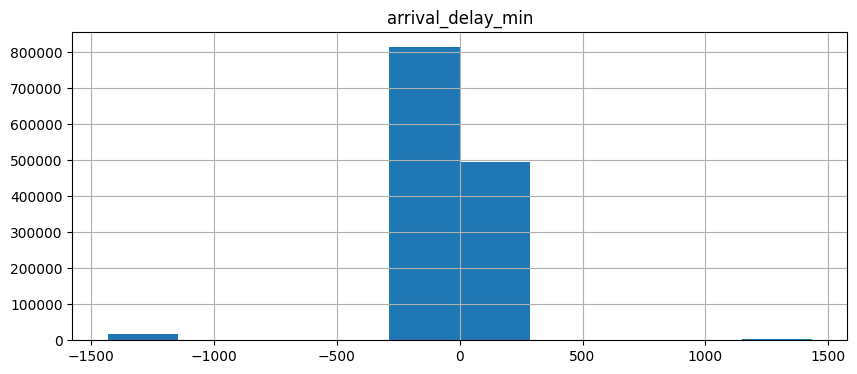

In [15]:
features = ["arrival_delay_min"]
df[features].hist(figsize=(10, 4));

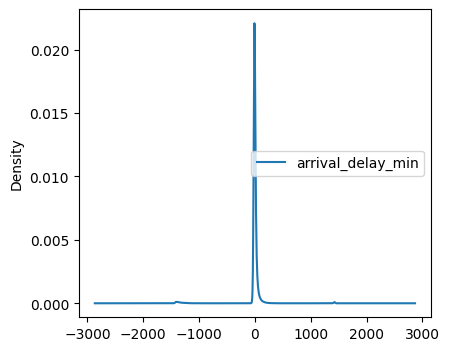

In [16]:
df[features].plot(
    kind="density", subplots=True, layout=(1, 2), sharex=False, figsize=(10, 4)
);

Histogram i wykres gęstości pokazuje, żę większość opóżnień jest blisko 0 (wcześniej policzona wartość równa -4), częściej wystepuje opóżnienie lotu niż wcześniejszy przylot. 
Wcześniej obliczona wartość odchylenia standardowego pokazuje, że jednak wiele lotów jest rozsianych na szerokim zakresie wartości opóżnień. Występuje duża zmienność opóźnień, są zaróno duże opóźnienia jak i przyspieszenia lotu

Aby lepiej przedstawić wartości odstające wyznaczamy wykres pudełkowy.

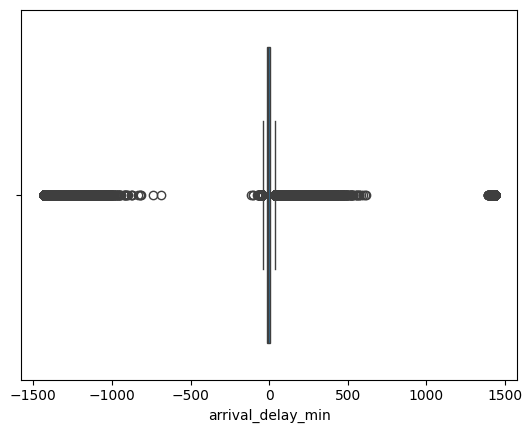

In [17]:
sns.boxplot(x="arrival_delay_min", data=df);

Wykres pokazuje, że mediana jest bliska 0, zatem większość lotów jest blisko planu z leką tendencją do małych opóźnień. Duza liczba wartości odstających po lewej stronie jest rozproszona pomiedzy wartosciami -1500 do -500.

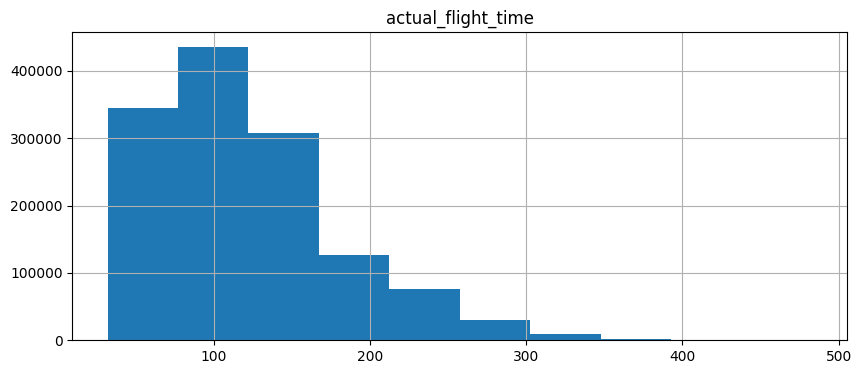

In [18]:
features = ["actual_flight_time"]
df[features].hist(figsize=(10, 4));

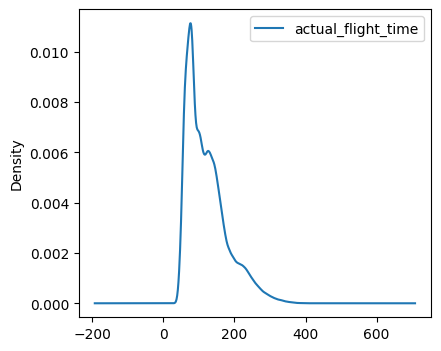

In [19]:
df[features].plot(
    kind="density", subplots=True, layout=(1, 2), sharex=False, figsize=(10, 4)
);

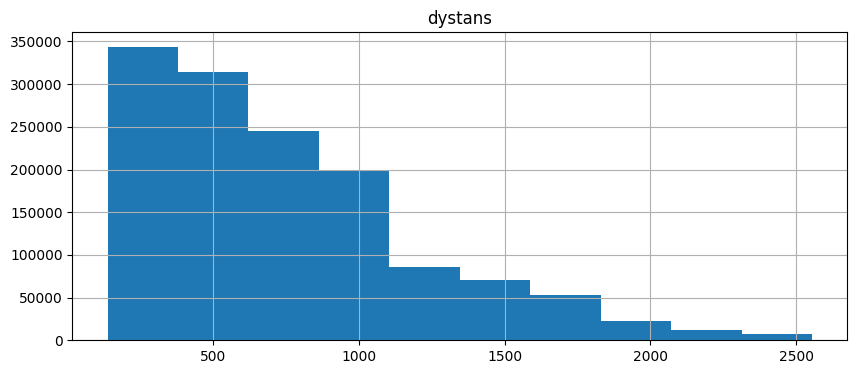

In [20]:
features = ["dystans"]
df[features].hist(figsize=(10, 4));

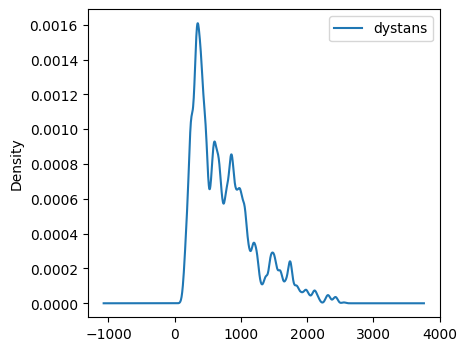

In [21]:
df[features].plot(
    kind="density", subplots=True, layout=(1, 2), sharex=False, figsize=(10, 4)
);

## Wykresy słupkowe dla zgrupowanych danych

Zbadajmy dane w podziale na poszczególne miesiące

In [22]:
df['flight_date'] = pd.to_datetime(df['flight_date'], errors='coerce', format='%Y-%m-%d')
df['month'] = df['flight_date'].dt.month

Średnie opóźnienie dla każdego miesiąca

month
1     27.849795
2     36.694429
3     38.753441
4     45.751596
5     51.391040
6     53.173228
7     64.570317
8     52.842099
9     28.803591
10    26.488862
11    36.020511
12    42.173255
Name: arrival_delay_min, dtype: float64


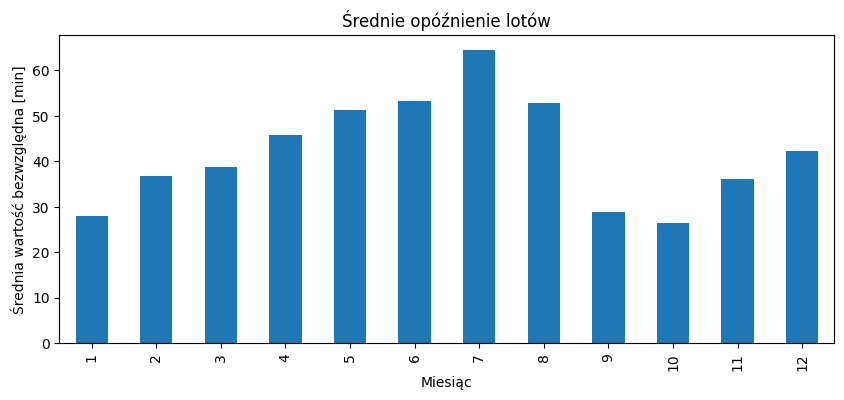

In [23]:
delayed_flights = df[df['arrival_delay_min'] < 0]
monthly_avg_delay = delayed_flights.groupby('month')['arrival_delay_min'].apply(lambda x: x.abs().mean())

print(monthly_avg_delay)

monthly_avg_delay.plot(kind='bar', figsize=(10, 4), title='Średnie opóźnienie lotów')
pl.ylabel('Średnia wartość bezwzględna [min]')
pl.xlabel('Miesiąc')
pl.show()


Średnie opóźnienia lotów są wyższe w miesiącach wakacyjnych, które mają największe obłożenie lotów, co sugeruje możliwą korelację między liczbą lotów a opóźnieniami.

    month  num_flights  avg_abs_delay
0       1       109676      27.849795
1       2        97017      36.694429
2       3       116420      38.753441
3       4       114117      45.751596
4       5       116849      51.391040
5       6       115939      53.173228
6       7       120114      64.570317
7       8       115534      52.842099
8       9       106972      28.803591
9      10       114663      26.488862
10     11       112224      36.020511
11     12       113027      42.173255
Korelacja: 0.56


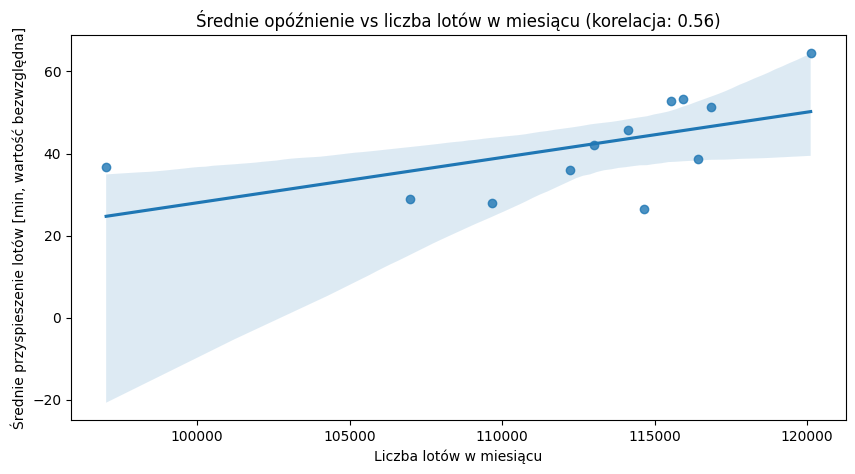

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

monthly_counts = df.groupby('month')['flight_id'].count().reset_index(name='num_flights')
delayed_flights = df[df['arrival_delay_min'] < 0]
monthly_avg_delay = delayed_flights.groupby('month')['arrival_delay_min'].apply(lambda x: x.abs().mean()).reset_index(name='avg_abs_delay')

monthly_data = monthly_counts.merge(monthly_avg_delay, on='month')

print(monthly_data)

corr = np.corrcoef(monthly_data['num_flights'], monthly_data['avg_abs_delay'])[0, 1]
print(f"Korelacja: {corr:.2f}")

pl.figure(figsize=(10, 5))
sns.regplot(x='num_flights', y='avg_abs_delay', data=monthly_data)
pl.xlabel('Liczba lotów w miesiącu')
pl.ylabel('Średnie przyspieszenie lotów [min, wartość bezwzględna]')
pl.title(f'Średnie opóźnienie vs liczba lotów w miesiącu (korelacja: {corr:.2f})')
pl.show()


start_airport
CVG    10.003513
CRP    10.152999
LGB    10.765138
LIT    10.817427
DSM    11.015737
         ...    
STL    58.305779
LAX    58.512942
ATL    72.307888
DEN    83.016221
EWR    87.020250
Name: arrival_delay_min, Length: 86, dtype: float64


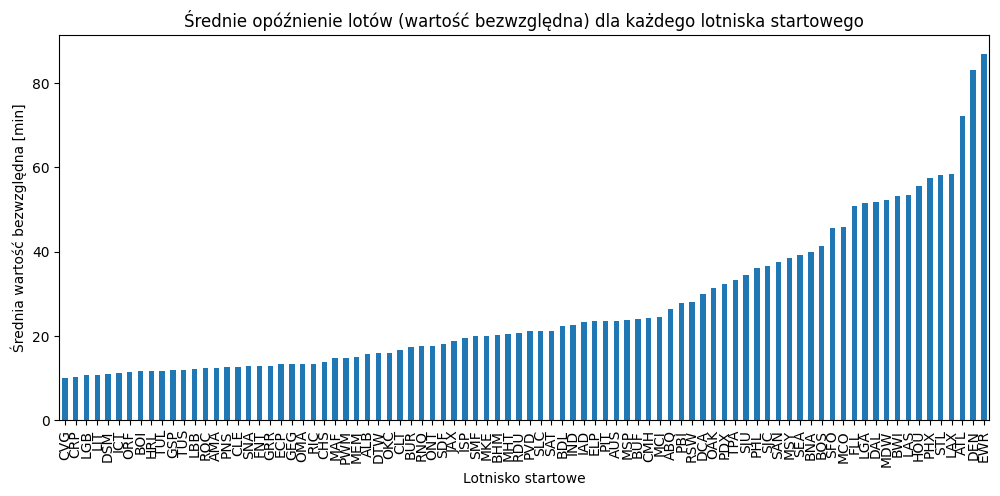

In [25]:
delayed_flights = df[df['arrival_delay_min'] < 0].copy()
airport_avg_delay = delayed_flights.groupby('start_airport')['arrival_delay_min'].apply(lambda x: x.abs().mean())
airport_avg_delay = airport_avg_delay.sort_values()

print(airport_avg_delay)

airport_avg_delay.plot(kind='bar', figsize=(12, 5), title='Średnie opóźnienie lotów (wartość bezwzględna) dla każdego lotniska startowego')
pl.ylabel('Średnia wartość bezwzględna [min]')
pl.xlabel('Lotnisko startowe')
pl.show()


In [26]:
df.head()

,flight_id,actual_arrival,actual_departure,actual_flight_time,cancellation_code,cancellation_status,dystans,end_airport,flight_date,flight_number,samolot_id,scheduled_arrival,scheduled_departure,scheduled_flight_time,start_airport,zaloga_id,arrival_delay_min,is_delayed,month
0,2681824,1753.0,1518.0,95.0,NaN,0,601,DCA,2018-05-20,2279,NaN,1800,1515,105,MDW,NaN,-7.0,False,5
1,2681825,804.0,536.0,88.0,NaN,0,601,DCA,2018-05-20,2391,NaN,825,545,100,MDW,NaN,-21.0,False,5
2,2681826,1517.0,1221.0,116.0,NaN,0,601,DCA,2018-05-20,2652,NaN,1500,1220,100,MDW,NaN,17.0,True,5
3,2681827,2227.0,1950.0,97.0,NaN,0,601,DCA,2018-05-20,2887,NaN,2200,1915,105,MDW,NaN,27.0,True,5
4,2681828,1107.0,818.0,109.0,NaN,0,601,DCA,2018-05-20,3243,NaN,1105,820,105,MDW,NaN,2.0,True,5


## Normalizacja

Funkcja pomocnicza do konwersji godziny w formacie HHMM na minuty

In [27]:
def hhmm_to_minutes(x):
    if pd.isna(x):
        return np.nan
    h = int(x) // 100
    m = int(x) % 100
    return h * 60 + m



Konwersja godziny na minuty

In [28]:
df['actual_arrival_min'] = df['actual_arrival'].apply(hhmm_to_minutes)
df['sched_arrival_min'] = df['scheduled_arrival'].apply(hhmm_to_minutes)

Dla cech cyklicznych obliczamy sin i cos

In [29]:
df['actual_arrival_sin'] = np.sin(2 * np.pi * df['actual_arrival_min'] / 1440)
df['actual_arrival_cos'] = np.cos(2 * np.pi * df['actual_arrival_min'] / 1440)

df['sched_arrival_sin'] = np.sin(2 * np.pi * df['sched_arrival_min'] / 1440)
df['sched_arrival_cos'] = np.cos(2 * np.pi * df['sched_arrival_min'] / 1440)

df['arrival_delay_sin'] = np.sin(2 * np.pi * df['arrival_delay_min'] / 1440)
df['arrival_delay_cos'] = np.cos(2 * np.pi * df['arrival_delay_min'] / 1440)

Normalizujemy cechy numeryczne

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

df[['dystans', 'scheduled_flight_time', 'actual_flight_time', 'arrival_delay_min']] = scaler.fit_transform(
    df[['dystans', 'scheduled_flight_time', 'actual_flight_time', 'arrival_delay_min']]
)

Na podstawie daty wyciagamy dzien roku w celu zastosowania tej informacji w macierzy korelacji

In [32]:
df['flight_day_of_year'] = df['flight_date'].dt.dayofyear

Dzień w roku jest cechą cykliczną, więc wyznaczamy sin/cos

In [33]:
import numpy as np

df['flight_day_of_year_sin'] = np.sin(2 * np.pi * df['flight_day_of_year'] / 365)
df['flight_day_of_year_cos'] = np.cos(2 * np.pi * df['flight_day_of_year'] / 365)

Po normalizacji, usuwany kolumny zrodlowe ktorych juz nie uzywamy

In [34]:
df = df.drop(columns=['actual_arrival', 'actual_arrival_min', 'sched_arrival_min', 'scheduled_arrival'])

In [35]:
df.head()

,flight_id,actual_departure,actual_flight_time,cancellation_code,cancellation_status,dystans,end_airport,flight_date,flight_number,samolot_id,...,month,actual_arrival_sin,actual_arrival_cos,sched_arrival_sin,sched_arrival_cos,arrival_delay_sin,arrival_delay_cos,flight_day_of_year,flight_day_of_year_sin,flight_day_of_year_cos
0,2681824,1518.0,-0.463994,NaN,0,-0.319487,DCA,2018-05-20,2279,NaN,...,5,-0.999534,-0.030539,-1.000000,-1.836970e-16,-0.030539,0.999534,140,0.668064,-0.744104
1,2681825,536.0,-0.586270,NaN,0,-0.319487,DCA,2018-05-20,2391,NaN,...,5,0.857167,-0.515038,0.806445,-5.913096e-01,-0.091502,0.995805,140,0.668064,-0.744104
2,2681826,1221.0,-0.097166,NaN,0,-0.319487,DCA,2018-05-20,2652,NaN,...,5,-0.757565,-0.652760,-0.707107,-7.071068e-01,0.074108,0.997250,140,0.668064,-0.744104
3,2681827,1950.0,-0.429058,NaN,0,-0.319487,DCA,2018-05-20,2887,NaN,...,5,-0.394744,0.918791,-0.500000,8.660254e-01,0.117537,0.993068,140,0.668064,-0.744104
4,2681828,818.0,-0.219442,NaN,0,-0.319487,DCA,2018-05-20,3243,NaN,...,5,0.229200,-0.973379,0.237686,-9.713421e-01,0.008727,0.999962,140,0.668064,-0.744104


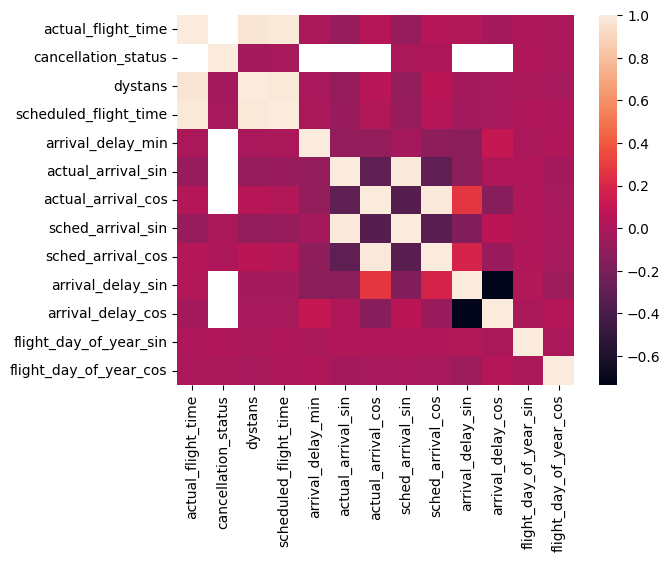

In [36]:
numerical = df.select_dtypes(include=['float64', 'int64']).columns

numerical = [col for col in numerical if col not in ['samolot_id', 'zaloga_id', 'flight_day_of_year', 'flight_id', 
                                                     'flight_number', 'scheduled_departure', 'actual_departure', 'is_delayed']]

corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix);

Z wygenerowanej wyżej macierzy korelacji wynika, że actual_flight_time, actual_arrival i cancellation_status to zmienne zależne, więc możemy je usunąć

In [37]:
numerical = list(
    set(numerical)
    - set(
        [
            "actual_flight_time",
            "cancellation_status",
        ]
    )
)

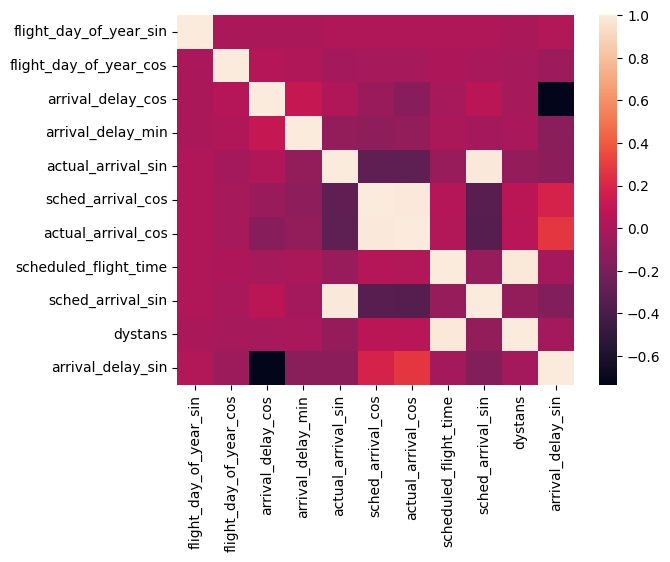

In [38]:
corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix);